Extracting EDF parameters from shhs1-200001.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4064999  =      0.000 ... 32519.992 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 4125 samples (33.000 s)


=== Channel Names ===
['SaO2', 'H.R.', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'THOR RES', 'ABDO RES', 'POSITION', 'LIGHT', 'NEW AIR', 'OX stat']
Not setting metadata
1084 matching events found
No baseline correction applied
0 projection items acti

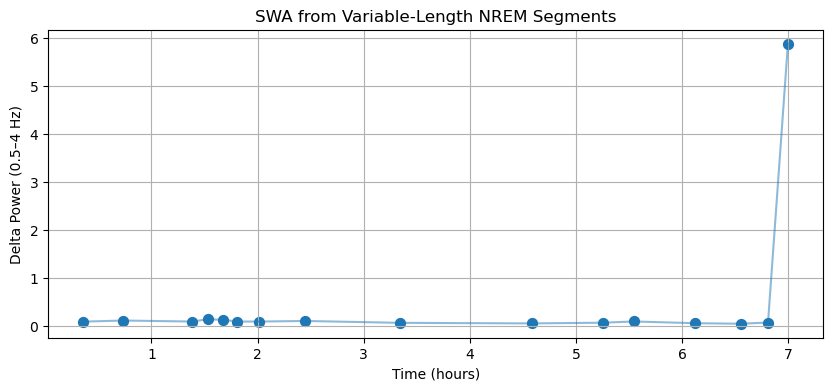

Saved: swa_variable_segments.csv
Saved: swa_summary_variable_segments.csv

=== Summary ===
   SWA_mean   SWA_std  Num_segments  Mean_duration_min
0  0.442521  1.405205            16           17.34375


In [8]:
# =========================
# STEP 1 — Imports & warnings
# =========================
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yasa
from scipy.signal import medfilt
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", message=".*'S' is deprecated.*", category=FutureWarning)

# =========================
# STEP 2 — Load & filter EEG
# =========================
raw = mne.io.read_raw_edf("shhs1-200001.edf", preload=True)
raw.filter(0.1, 35)

print("\n=== Channel Names ===")
print(raw.ch_names)

# =========================
# STEP 3 — Sleep staging
# =========================
sls = yasa.SleepStaging(
    raw,
    eeg_name="EEG(sec)",
    eog_name="EOG(L)",
    emg_name="EMG"
)

hypno = sls.predict()

# =========================
# STEP 4 — Convert + smooth
# =========================
mapping = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
hypno_int = np.array([mapping[h] for h in hypno])

# 90s smoothing
hypno_smooth = medfilt(hypno_int, kernel_size=3)

# =========================
# STEP 5 — Create epochs (30s)
# =========================
epochs = mne.make_fixed_length_epochs(raw, duration=30, preload=True)

# =========================
# STEP 6 — Find variable-length NREM segments ≥ 5 min
# =========================
nrem_mask = np.isin(hypno_smooth, [1, 2, 3])

epoch_len = 30
min_epochs = (5 * 60) // epoch_len  # 10 epochs

segments = []
start = None

for i, val in enumerate(nrem_mask):
    if val and start is None:
        start = i
    elif not val and start is not None:
        end = i
        if (end - start) >= min_epochs:
            segments.append((start, end))
        start = None

# handle last segment
if start is not None:
    end = len(nrem_mask)
    if (end - start) >= min_epochs:
        segments.append((start, end))

print("\n=== Valid NREM segments (>=5 min) ===")
print(segments)

# =========================
# STEP 7 — Compute TFR per segment
# =========================
freqs = np.linspace(0.5, 20, 25)
n_cycles = freqs / 2.0

times_all = []
delta_all = []
durations = []
all_matrix_dfs = []

for seg_idx, (start, end) in enumerate(segments):

    seg_epochs = epochs[start:end]
    if len(seg_epochs) == 0:
        continue

    power = seg_epochs.compute_tfr(
        method="multitaper",
        freqs=freqs,
        n_cycles=n_cycles,
        return_itc=False,
        average=True
    )

    # (channels × freqs × time) → (freqs × time)
    matrix = power.data.mean(axis=0)

    # Remove edge artifacts
    valid = (power.times > 2) & (power.times < power.times.max() - 2)
    matrix = matrix[:, valid]
    times = power.times[valid]

    # Delta power (0.5–4 Hz)
    delta_mask = (freqs >= 0.5) & (freqs <= 4)
    delta_power = matrix[delta_mask, :].mean()

    # Time (midpoint of segment in hours)
    mid_epoch = (start + end) / 2
    time_hr = mid_epoch * 30 / 3600

    # Duration (minutes)
    duration_min = (end - start) * 30 / 60

    # Collect SWA features
    times_all.append(time_hr)
    delta_all.append(delta_power)
    durations.append(duration_min)

    # Build matrix DataFrame (freq × time)
    df_matrix = pd.DataFrame(
        matrix,
        index=np.round(freqs, 2),
        columns=np.round(times, 2)
    )

    # Convert to long format
    df_long = df_matrix.stack().reset_index()
    df_long.columns = ["Frequency", "Time", "Power"]

    df_long["Segment"] = seg_idx
    df_long["Duration_min"] = duration_min

    all_matrix_dfs.append(df_long)

# =========================
# STEP 8 — Save combined matrix
# =========================
if len(all_matrix_dfs) > 0:
    final_matrix_df = pd.concat(all_matrix_dfs, ignore_index=True)
    final_matrix_df.to_csv("all_segments_matrix.csv", index=False)
    print("Saved: all_segments_matrix.csv")
else:
    print("No valid segments found.")

# =========================
# STEP 9 — Create SWA DataFrame
# =========================
df = pd.DataFrame({
    "Time_hr": times_all,
    "Delta_Power": delta_all,
    "Duration_min": durations
})

print("\n=== Data preview ===")
print(df.head())

# =========================
# STEP 10 — Plot SWA
# =========================
plt.figure(figsize=(10, 4))
plt.scatter(df["Time_hr"], df["Delta_Power"], s=50)
plt.plot(df["Time_hr"], df["Delta_Power"], alpha=0.5)

plt.xlabel("Time (hours)")
plt.ylabel("Delta Power (0.5–4 Hz)")
plt.title("SWA from Variable-Length NREM Segments")
plt.grid(True)
plt.show()

# =========================
# STEP 11 — Save SWA results
# =========================
df.to_csv("swa_variable_segments.csv", index=False)
print("Saved: swa_variable_segments.csv")

# =========================
# STEP 12 — Summary features
# =========================
summary = {
    "SWA_mean": np.mean(delta_all) if len(delta_all) else np.nan,
    "SWA_std": np.std(delta_all) if len(delta_all) else np.nan,
    "Num_segments": len(delta_all),
    "Mean_duration_min": np.mean(durations) if len(durations) else np.nan
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("swa_summary_variable_segments.csv", index=False)

print("Saved: swa_summary_variable_segments.csv")

print("\n=== Summary ===")
print(summary_df)

In [7]:
import mne
print(mne.__version__)

1.12.0
